Detected Event Years: {'telebirr': np.int32(2021), 'mpesa': np.int32(2023), 'fayda': np.int32(2024), 'fx_reform': np.int32(2024), 'nfis2': np.int32(2021)}
⚠ Not enough usage data points for forecasting.
Model features: ['const', 'year', 'telebirr', 'mpesa', 'fayda', 'fx_reform', 'nfis2']

=== Access Forecast (2025–2027) ===


c:\Users\HP\Downloads\Mercy's\Mih\Kiam\week 10\ethiopia-fi-forecast\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
c:\Users\HP\Downloads\Mercy's\Mih\Kiam\week 10\ethiopia-fi-forecast\venv\Lib\site-packages\statsmodels\regression\_prediction.py:201: RuntimeWarning: invalid value encountered in dot
  var_pred_mean = (exog * np.dot(covb, exog.T).T).sum(1)


,year,access_forecast,access_lower_ci,access_upper_ci
0,2025,53.333333,NaN,NaN
1,2026,57.666667,NaN,NaN
2,2027,62.000000,NaN,NaN


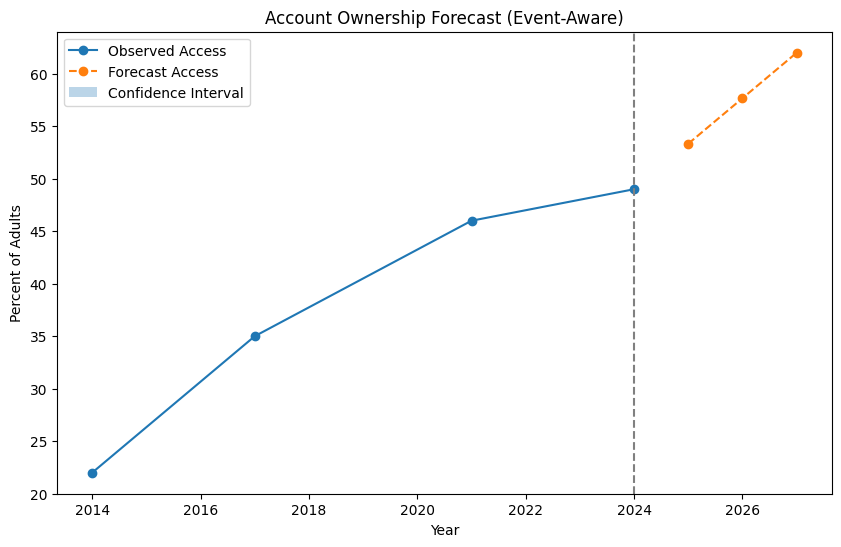

In [7]:
# =========================
# Task 4: Forecasting (Self-Contained, Event-Aware)
# =========================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path

# -------------------------
# Load Data Safely
# -------------------------
DATA_PATH = Path("../data/processed/ethiopia_fi_enriched.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"File not found: {DATA_PATH}. Run Task 1 first.")

df = pd.read_csv(DATA_PATH)
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")

# -------------------------
# Separate observations and events
# -------------------------
obs = df[df["record_type"] == "observation"].copy()
events_df = df[df["record_type"] == "event"].copy()

# -------------------------
# Prepare ACCESS: Account Ownership
# -------------------------
access = obs[
    (obs["indicator_code"] == "ACC_OWNERSHIP") &
    (obs["gender"] == "all")
].copy()

access["year"] = access["observation_date"].dt.year
access = access.dropna(subset=["year", "value_numeric"]).sort_values("year")

# -------------------------
# Prepare USAGE: Mobile Money Activity Rate
# -------------------------
usage = obs[
    obs["indicator_code"].isin(["USG_ACTIVE_RATE"])
].copy()

usage["year"] = usage["observation_date"].dt.year
usage = usage.dropna(subset=["year", "value_numeric"]).sort_values("year")

# -------------------------
# Rebuild Event Years (IMPORTANT FIX)
# -------------------------
event_map = {
    "telebirr": "EVT_TELEBIRR",
    "mpesa": "EVT_MPESA",
    "fayda": "EVT_FAYDA",
    "fx_reform": "EVT_FX_REFORM",
    "nfis2": "EVT_NFIS2"
}

event_years = {}
for name, code in event_map.items():
    row = events_df[events_df["indicator_code"] == code]
    if len(row) > 0:
        event_years[name] = pd.to_datetime(row["observation_date"]).dt.year.iloc[0]

print("Detected Event Years:", event_years)

# -------------------------
# Create Event Dummies
# -------------------------
for name, year in event_years.items():
    access[name] = (access["year"] >= year).astype(int)
    usage[name] = (usage["year"] >= year).astype(int)

# -------------------------
# Fit Event-Aware Models
# -------------------------
X_acc = sm.add_constant(access[["year"] + list(event_years.keys())])
y_acc = access["value_numeric"]
access_model = sm.OLS(y_acc, X_acc).fit()

if len(usage) >= 3:
    X_use = sm.add_constant(usage[["year"] + list(event_years.keys())])
    y_use = usage["value_numeric"]
    usage_model = sm.OLS(y_use, X_use).fit()
else:
    usage_model = None
    print("⚠ Not enough usage data points for forecasting.")

# -------------------------
# Forecast Horizon
# -------------------------
future_years = pd.DataFrame({"year": [2025, 2026, 2027]})

for name, year in event_years.items():
    future_years[name] = (future_years["year"] >= year).astype(int)

# -------------------------
# Align Forecast Design Matrix with Model
# -------------------------
model_features = access_model.model.exog_names  # exact columns used in training
print("Model features:", model_features)

X_future_acc = future_years.copy()

# Add constant if model used it
if "const" in model_features:
    X_future_acc = sm.add_constant(X_future_acc, has_constant="add")

# Add any missing columns that were in training but not in future
for col in model_features:
    if col not in X_future_acc.columns:
        X_future_acc[col] = 0

# Ensure correct column order
X_future_acc = X_future_acc[model_features]

# -------------------------
# Forecast ACCESS
# -------------------------
acc_forecast = access_model.get_prediction(X_future_acc).summary_frame(alpha=0.2)

forecast_access_df = pd.DataFrame({
    "year": future_years["year"],
    "access_forecast": acc_forecast["mean"],
    "access_lower_ci": acc_forecast["mean_ci_lower"],
    "access_upper_ci": acc_forecast["mean_ci_upper"]
})

print("\n=== Access Forecast (2025–2027) ===")
display(forecast_access_df)

# -------------------------
# Forecast USAGE
# -------------------------
if usage_model is not None:
    X_future_use = sm.add_constant(future_years[["year"] + list(event_years.keys())])
    use_forecast = usage_model.get_prediction(X_future_use).summary_frame(alpha=0.2)

    forecast_usage_df = pd.DataFrame({
        "year": future_years["year"],
        "usage_forecast": use_forecast["mean"],
        "usage_lower_ci": use_forecast["mean_ci_lower"],
        "usage_upper_ci": use_forecast["mean_ci_upper"]
    })

    print("\n=== Usage Forecast (2025–2027) ===")
    display(forecast_usage_df)
else:
    forecast_usage_df = None

# -------------------------
# Plot ACCESS
# -------------------------
plt.figure(figsize=(10,6))
plt.plot(access["year"], access["value_numeric"], "o-", label="Observed Access")
plt.plot(forecast_access_df["year"], forecast_access_df["access_forecast"], "o--", label="Forecast Access")
plt.fill_between(
    forecast_access_df["year"],
    forecast_access_df["access_lower_ci"],
    forecast_access_df["access_upper_ci"],
    alpha=0.3,
    label="Confidence Interval"
)
plt.axvline(access["year"].max(), linestyle="--", color="gray")
plt.title("Account Ownership Forecast (Event-Aware)")
plt.xlabel("Year")
plt.ylabel("Percent of Adults")
plt.legend()
plt.show()

# -------------------------
# Plot USAGE
# -------------------------
if forecast_usage_df is not None:
    plt.figure(figsize=(10,6))
    plt.plot(usage["year"], usage["value_numeric"], "o-", label="Observed Usage")
    plt.plot(forecast_usage_df["year"], forecast_usage_df["usage_forecast"], "o--", label="Forecast Usage")
    plt.fill_between(
        forecast_usage_df["year"],
        forecast_usage_df["usage_lower_ci"],
        forecast_usage_df["usage_upper_ci"],
        alpha=0.3,
        label="Confidence Interval"
    )
    plt.axvline(usage["year"].max(), linestyle="--", color="gray")
    plt.title("Mobile Money Usage Forecast (Event-Aware)")
    plt.xlabel("Year")
    plt.ylabel("Percent of Adults")
    plt.legend()
    plt.show()
